In [18]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
model = YOLO('runs/detect/TyreDetection_Project/exp_v1_yolov8s/weights/best.pt')

In [4]:
metrics = model.val()

Ultralytics 8.4.37  Python-3.12.0 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070, 12227MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 383.3165.8 MB/s, size: 1764.8 KB)
val: Scanning D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\valid\labels.cache... 8088 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8088/8088  0.0s
val: D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\valid\images\20251013-032425_jpg.rf.696fceb1eebddef32ee8e4fba5e83fb8_v0.jpg: 7 duplicate labels removed
val: D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\valid\images\20251021-004920_jpg.rf.0730434782b8a4d039b3d8fddea1dc5f_v2.jpg: 1 duplicate labels removed
val: D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\valid\images\20251021-004920_jpg.rf.0730434782b8a4d039b3d8fddea1dc5f_v3.jpg: 1 duplicate labels removed
val: D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\valid\ima

In [7]:
# Validation o'tkazish
results = model.val()

# Umumiy confusion matrix obyekti
cm = results.confusion_matrix

# Klasslar ro'yxatini olish
names = model.names

# Har bir klass uchun Precision, Recall va Matrix elementlarini ko'rish
for i, name in names.items():
    # confusion_matrix.matrix[klass_indexi] orqali ma'lumotlarni olamiz
    # Eslatma: YOLOda oxirgi indeks odatda "background" (fon) uchun
    tp = cm.matrix[i, i]          # To'g'ri topilganlar
    fp = cm.matrix[i, :].sum() - tp  # Boshqa narsani shu klass deb o'ylaganlari
    fn = cm.matrix[:, i].sum() - tp  # Shu klassni topa olmaganlari
    
    print(f"--- Class: {name} ---")
    print(f"True Positives (TP): {tp}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")
    print("-" * 20)

Ultralytics 8.4.37  Python-3.12.0 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070, 12227MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 1866.264.7 MB/s, size: 1635.3 KB)
val: Scanning D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\valid\labels.cache... 8088 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8088/8088  0.0s
val: D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\valid\images\20251013-032425_jpg.rf.696fceb1eebddef32ee8e4fba5e83fb8_v0.jpg: 7 duplicate labels removed
val: D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\valid\images\20251021-004920_jpg.rf.0730434782b8a4d039b3d8fddea1dc5f_v2.jpg: 1 duplicate labels removed
val: D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\valid\images\20251021-004920_jpg.rf.0730434782b8a4d039b3d8fddea1dc5f_v3.jpg: 1 duplicate labels removed
val: D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\valid\images\20251021-005210_jpg.rf.e6ebcfcf27067fb7a780ec2e7bbadb8d_v2.jpg: 1 duplicate la

In [11]:
%matplotlib inline

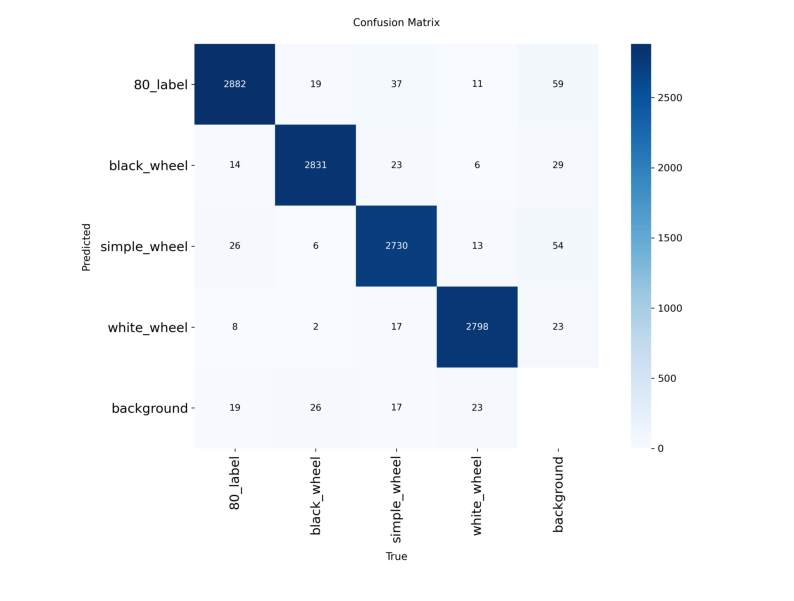

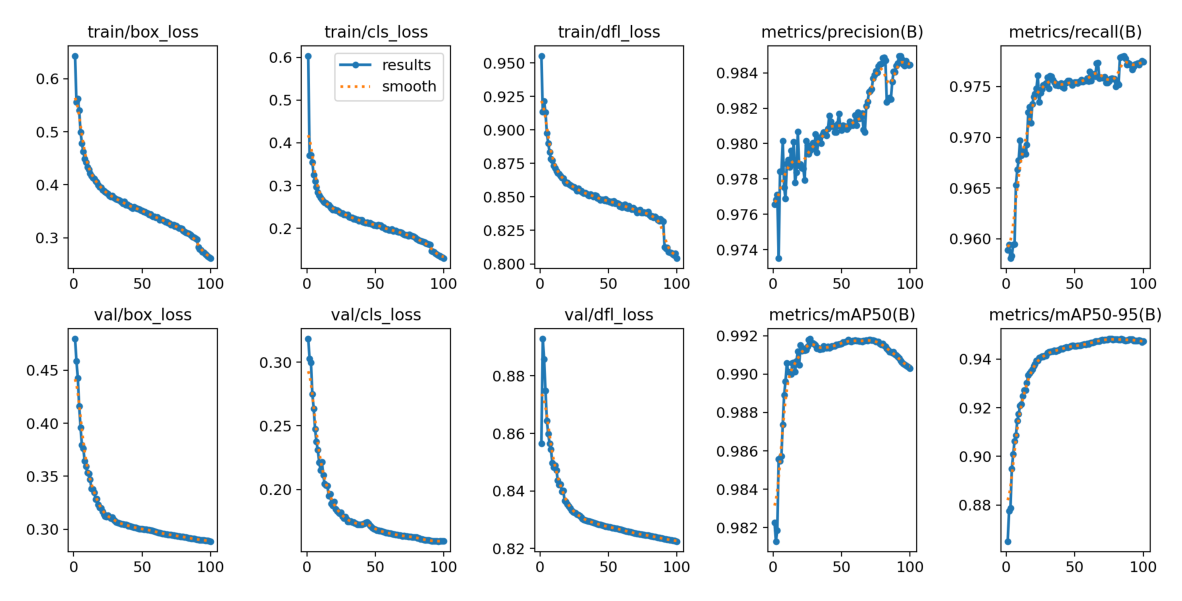

In [12]:
# Confusion Matrixni ko'rish
img = mpimg.imread('runs/detect/TyreDetection_Project/exp_v1_yolov8s/confusion_matrix.png')
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

# Training natijalari (Loss va mAP grafiklari)
img_results = mpimg.imread('runs/detect/TyreDetection_Project/exp_v1_yolov8s/results.png')
plt.figure(figsize=(15, 10))
plt.imshow(img_results)
plt.axis('off')
plt.show()

In [6]:
print(f"mAP50: {metrics.box.map50}") # Bu classlarni qanchalik aniq topdi va BBOX larni qanchalik aniq topganini o'rtacha precisionni(topgani) 50 - threshold
print(f"mAP50-95: {metrics.box.map}") # Bu objectni bboxni qanchalik to'g'ri chiganini har xil thresholdlarni o'rtachasi
print(f"Precision: {metrics.box.mp}") # Bu model topgan classlarni qanchasini aniq topganini ko'rsatadi
print(f"Recall: {metrics.box.mr}") # Bu model necha foiz objectni to'g'ri topdi

mAP50: 0.9917081138128216
mAP50-95: 0.949451097323778
Precision: 0.9842908881447127
Recall: 0.9757752622404267


In [13]:
results = model.predict(source='Dataset/Tyre_error_proofing.v15i.yolov9/test/images', save=True)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/3855 D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\test\images\20251012-113711_jpg.rf.bc80590262f4af934ed6f0c8bfbec32f.jpg: 384x640 1 80_label, 1 simple_wheel, 42.0ms
image 2/3855 D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\test\images\20251012-201506_jpg.rf.894418c2c20cdcc177e38826b9045356.jpg: 384x640 1 80_label, 1 simple_wheel, 9.6ms
image 3/3855 D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\test\images\20251

In [14]:
metrics = model.val(data='Dataset/Tyre_error_proofing.v15i.yolov9/data.yaml', split='test')

# Natijalarni ekranga chiqaramiz
print(f"Test mAP50: {metrics.box.map50}")
print(f"Test mAP50-95: {metrics.box.map}")
print(f"Test Precision: {metrics.box.mp}")
print(f"Test Recall: {metrics.box.mr}")

Ultralytics 8.4.37  Python-3.12.0 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070, 12227MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 961.6464.2 MB/s, size: 1157.5 KB)
val: Scanning D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\test\labels... 3855 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3855/3855 1.3Kit/s 3.1s<0.0s
val: D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\test\images\20251021-005641_jpg.rf.d89cec370ce9575b378842b9b119ee7c.jpg: 1 duplicate labels removed
val: D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\test\images\20251021-005739_jpg.rf.b8aedcf8e20e12fec868fec6804f74c7.jpg: 1 duplicate labels removed
val: D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\test\images\20251021-012003_jpg.rf.0f986f14e7a5d03c1cc4cb18864609c6.jpg: 1 duplicate labels removed
val: D:\tyreDetetction\Dataset\Tyre_error_proofing.v15i.yolov9\test\images\20251021-023712_jpg.rf.bdd0d727ca45d623bdc36cb8b2ff6683.jpg: 1 duplicate labels remov

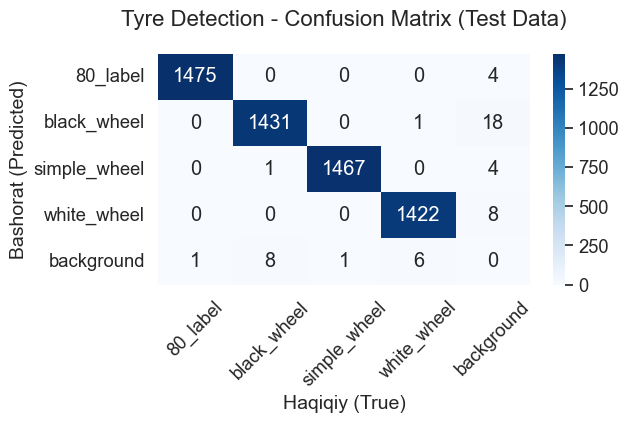

In [22]:
cm_array = metrics.confusion_matrix.matrix

names = list(model.names.values()) + ['background']

plt.figure(figsize=(6, 3))
sns.set_theme(font_scale=1.2)

sns.heatmap(cm_array, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=names, yticklabels=names)

plt.title('Tyre Detection - Confusion Matrix (Test Data)', fontsize=16, pad=20)
plt.xlabel('Haqiqiy (True)', fontsize=14)
plt.ylabel('Bashorat (Predicted)', fontsize=14)
plt.xticks(rotation=45)
plt.show()